In [ ]:
# Import dataset dari kaggle
import kagglehub
wenruliu_adult_income_dataset_path = kagglehub.dataset_download('wenruliu/adult-income-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'adult-income-dataset' dataset.
Data source import complete.


<p style="background-color:steelblue;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:60px 20px;"><b>Decision tree - Adult Income Prediction</b></p>

**Contains:**

- [Importing Libraries](#import-library)
- [Loading The Dataset](#loading-dataset)
- [Understanding The Dataset & EDA](#eda)
- [Data Pre-Processing](#data-pre)


<h1 style="color: steelblue;">Introduction</h1>

This project focuses on analyzing various demographic and socio-economic factors that influence the annual income levels of adult individuals in the United States. The dataset used includes variables such as age, education level, marital status, occupation, and working hours. Throughout the project, machine learning models were developed to predict whether an individual's income exceeds or falls below $50,000 using these variables. Comprehensive testing was conducted through data preprocessing, feature engineering, and the application of different algorithms, leading to the selection of the best-performing model. This study provides a foundation for understanding income inequality and developing predictive models for decision support systems.

<h1 id="import-library" style="color: steelblue;">Importing Libraries</h1>

In [ ]:
!pip install skimpy

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimpy import skim
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import make_column_transformer

plt.rcParams["figure.figsize"] = (8,6)

import warnings
warnings.filterwarnings("ignore")

<h1 id="loading-dataset" style="color: steelblue;">Loading The Dataset</h1>

In [ ]:
df0 = pd.read_csv("adult-income-dataset/adult.csv")
df = df0.copy()
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
df.sample(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
10527,31,Private,179673,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
27952,36,Private,177285,Assoc-voc,11,Never-married,Prof-specialty,Unmarried,Black,Female,0,0,38,United-States,<=50K
5532,34,?,112584,HS-grad,9,Separated,?,Unmarried,White,Female,0,0,40,United-States,<=50K
42330,21,Private,216129,HS-grad,9,Never-married,Other-service,Own-child,White,Male,0,0,35,United-States,<=50K
23856,42,Self-emp-not-inc,103980,Assoc-voc,11,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K


**Data Set Information:**

This dataset was obtained from UCI Machine Learning Repository. The aim of this problem is to classify adults in two different groups based on their income where group 1 has an income less than USD 50k and group 2 has an income of more than or equal to USD 50k. The data available at hand comes from Census 1994.

**Attribute Information:**

**Age**: Describes the age of individuals. Continuous.

**Workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.

**fnlwgt**: Continuous value. This is a weighting factor created by the Census Bureau in the United States and indicates the number of people each data entry actually represents. For example, when the fnlwgt value for a data entry is 100, that data entry is considered to represent 100 people.

However, this feature is generally not used directly in analysis or model training because these weights do not have a direct bearing on individual data points when training or testing the model. However, if a more in-depth demographic analysis is being done on the data set, these weight values ​​may be useful.

**education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.

**education-num**: Number of years spent in education. Continuous.

**marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.

**occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.

**relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.

**race**: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.

**gender**: Female, Male.

**capital-gain**: Continuous values ​​that represent an individual's gain from asset sales (for example, the sale of stocks or real estate).

**capital-loss**: Continuous value that represents the loss incurred by an individual from the sale of assets (for example, the sale of stocks or real estate).

**hours-per-week**: The total working hours per week. Continuous.

**native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

**salary**: >50K,<=50K.

<h1 id="eda" style="color: steelblue;">Understanding Data & EDA</h1>

In [ ]:
df.shape

(48842, 15)

In [ ]:
df.columns = df.columns.str.replace(".", "_")
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')

In [ ]:
# Checks for duplicate observations in the dataset and removes them if found

def duplicate_values(df):
    print("Duplicate check...")
    num_duplicates = df.duplicated(subset=None, keep="first").sum()
    if num_duplicates > 0:
        print("There are", num_duplicates, "duplicated observations in the dataset.")
        df.drop_duplicates(keep="first", inplace=True)
        print(num_duplicates, "duplicates were dropped!")
        print("No more duplicate rows!")
    else:
        print("There are no duplicated observations in the dataset.")

duplicate_values(df)

Duplicate check...
There are 52 duplicated observations in the dataset.
52 duplicates were dropped!
No more duplicate rows!


In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48790 non-null  int64
 1   workclass        48790 non-null  str  
 2   fnlwgt           48790 non-null  int64
 3   education        48790 non-null  str  
 4   educational-num  48790 non-null  int64
 5   marital-status   48790 non-null  str  
 6   occupation       48790 non-null  str  
 7   relationship     48790 non-null  str  
 8   race             48790 non-null  str  
 9   gender           48790 non-null  str  
 10  capital-gain     48790 non-null  int64
 11  capital-loss     48790 non-null  int64
 12  hours-per-week   48790 non-null  int64
 13  native-country   48790 non-null  str  
 14  income           48790 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.7 MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48790.0,38.652798,13.708493,17.0,28.0,37.0,48.00,90.0
fnlwgt,48790.0,189668.999365,105617.231232,12285.0,117555.0,178138.5,237606.25,1490400.0
educational-num,48790.0,10.078807,2.570046,1.0,9.0,10.0,12.00,16.0
capital-gain,48790.0,1080.217688,7455.905921,0.0,0.0,0.0,0.00,99999.0
capital-loss,48790.0,87.595573,403.209129,0.0,0.0,0.0,0.00,4356.0
hours-per-week,48790.0,40.425886,12.392729,1.0,40.0,40.0,45.00,99.0


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
workclass,48790,9,Private,33860
education,48790,16,HS-grad,15770
marital-status,48790,7,Married-civ-spouse,22366
occupation,48790,15,Prof-specialty,6165
relationship,48790,6,Husband,19703
race,48790,5,White,41714
gender,48790,2,Male,32614
native-country,48790,42,United-States,43792
income,48790,2,<=50K,37109


In [ ]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [ ]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 48790  │ │ string      │ 9     │                                                          │
│ │ Number of columns │ 15     │ │ int64       │ 6     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column            ┃ NA  ┃ NA %  ┃ mean    ┃ sd      ┃ p0     ┃ p25    ┃ p50    ┃ p75    ┃ p100    ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩  │
│ │        age        │   0 │     0 │   38.65 │   13.71 │     17 │     28 │     37 │     48 │      90 │ ██▆▃▁  │  │
│ │      fnlwgt       │   0 │     0 │  189700 │  105600 │  12280 │ 117600 │ 178100 │ 237600 │ 1490000 │   █▂   │  │
│ │  educational-num  │   0 │     0 │   10.08 │    2.57 │      1 │      9 │     10 │     12 │      16 │  ▁▁█▄▁ │  │
│ │   capital-gain    │   0 │     0 │    1080 │    7456 │      0 │      0 │      0 │      0 │  100000 │   █    │  │
│ │   capital-loss    │   0 │     0 │    87.6 │   403.2 │      0 │      0 │      0 │      0 │    4356 │   █    │  │
│ │  hours-per-week   │   0 │     0 │   40.43 │   12.39 │      1 │     40 │     40 │     45 │      99 │  ▁▂█▂  │  │
│ └───────────────────┴─────┴───────┴─────────┴─────────┴────────┴────────┴────────┴────────┴─────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃          ┃           ┃           ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min       ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ workclass │  0 │    0 │    ?     │ Self-emp- │     ?     │ Without-p │       7.87 │         1 │      48790 │  │
│ │           │    │      │          │  not-inc  │           │    ay     │            │           │            │  │
│ │ education │  0 │    0 │   9th    │ Some-coll │   10th    │ Some-coll │       8.42 │         1 │      48790 │  │
│ │           │    │      │          │    ege    │           │    ege    │            │           │            │  │
│ │ marital-s │  0 │    0 │ Widowed  │ Married-s │ Divorced  │  Widowed  │       14.4 │         1 │      48790 │  │
│ │   tatus   │    │      │          │ pouse-abs │           │           │            │           │            │  │
│ │           │    │      │          │    ent    │           │           │            │           │            │  │
│ │ occupatio │  0 │    0 │    ?     │ Machine-o │     ?     │ Transport │       12.2 │         1 │      48790 │  │
│ │     n     │    │      │          │ p-inspct  │           │  -moving  │            │           │            │  │
│ │ relations │  0 │    0 │   Wife   │ Other-rel │  Husband  │   Wife    │       9.14 │         1 │      48790 │  │
│ │    hip    │    │      │          │   ative   │      

<h2 id="eda1" style="color: skyblue;">Checking Object Columns</h2>

<h3 id="o1" style="color: steelblue;">"workclass" Column</h3>

In [ ]:
df.workclass.isnull().sum()

np.int64(0)

In [ ]:
df.workclass.unique()

<ArrowStringArray>
[         'Private',        'Local-gov',                '?',
 'Self-emp-not-inc',      'Federal-gov',        'State-gov',
     'Self-emp-inc',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

This column contains the value '**?**'. This value is actually NaN value. Let's convert this value from str dtype to nan dtype.

In [ ]:
df['workclass'] = df['workclass'].replace('?', np.nan)

In [ ]:
df.workclass.value_counts()

workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

In [ ]:
df.workclass.isnull().sum() # '?' values ​​have turned into NaN values. NaN values will be checked in NaN Values section.

np.int64(2795)

<h3 id="o2" style="color: steelblue;">"education" Column</h3>

In [ ]:
df.education.unique()

<ArrowStringArray>
[        '11th',      'HS-grad',   'Assoc-acdm', 'Some-college',
         '10th',  'Prof-school',      '7th-8th',    'Bachelors',
      'Masters',    'Doctorate',      '5th-6th',    'Assoc-voc',
          '9th',         '12th',      '1st-4th',    'Preschool']
Length: 16, dtype: str

This column seems OK for now.

<h3 id="o3" style="color: steelblue;">"marital-status" Column</h3>

In [ ]:
df['marital-status'].unique()

<ArrowStringArray>
[        'Never-married',    'Married-civ-spouse',               'Widowed',
              'Divorced',             'Separated', 'Married-spouse-absent',
     'Married-AF-spouse']
Length: 7, dtype: str

This column seems OK for now.

<h3 id="o4" style="color: steelblue;">"occupation" Column</h3>

In [ ]:
df.occupation.isnull().sum()

np.int64(0)

In [ ]:
df.occupation.unique()

<ArrowStringArray>
['Machine-op-inspct',   'Farming-fishing',   'Protective-serv',
                 '?',     'Other-service',    'Prof-specialty',
      'Craft-repair',      'Adm-clerical',   'Exec-managerial',
      'Tech-support',             'Sales',   'Priv-house-serv',
  'Transport-moving', 'Handlers-cleaners',      'Armed-Forces']
Length: 15, dtype: str

This column contains the value '**?**' too. This value is actually NaN value. Let's convert this value from str type to nan type.

In [ ]:
df['occupation'] = df['occupation'].replace('?', np.nan)

In [ ]:
df.occupation.value_counts()

occupation
Prof-specialty       6165
Craft-repair         6102
Exec-managerial      6082
Adm-clerical         5606
Sales                5501
Other-service        4919
Machine-op-inspct    3017
Transport-moving     2355
Handlers-cleaners    2071
Farming-fishing      1485
Tech-support         1445
Protective-serv       982
Priv-house-serv       240
Armed-Forces           15
Name: count, dtype: int64

In [ ]:
df.occupation.isnull().sum() # '?' values ​​have turned into NaN values. NaN values will be checked in NaN Values section.

np.int64(2805)

<h3 id="o5" style="color: steelblue;">"relationship" Column</h3>

In [ ]:
df.relationship.unique()

<ArrowStringArray>
['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife',
 'Other-relative']
Length: 6, dtype: str

This column seems OK for now.

<h3 id="o6" style="color: steelblue;">"race" Column</h3>

In [ ]:
df.race.unique()

<ArrowStringArray>
['Black', 'White', 'Asian-Pac-Islander', 'Other', 'Amer-Indian-Eskimo']
Length: 5, dtype: str

This column seems OK for now.

<h3 id="o7" style="color: steelblue;">"gender" Column</h3>

In [ ]:
df.gender.unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

This column seems OK for now.

<h3 id="o8" style="color: steelblue;">"native-country" Column</h3>

In [ ]:
df.drop(columns=['native-country'], inplace=True)

<h3 id="o9" style="color: steelblue;">"income" Column</h3>

In [ ]:
df.income.unique()

<ArrowStringArray>
['<=50K', '>50K']
Length: 2, dtype: str

This column seems OK for now.

In [ ]:
df.isnull().sum()

age                   0
workclass          2795
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2805
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
income                0
dtype: int64

In [ ]:
df.isnull().sum().sum()

np.int64(5600)

<h2 id="eda2" style="color: skyblue;">Checking Numeric Columns</h2>

<h3 id="out1" style="color: steelblue;">Checking Outliers</h3>

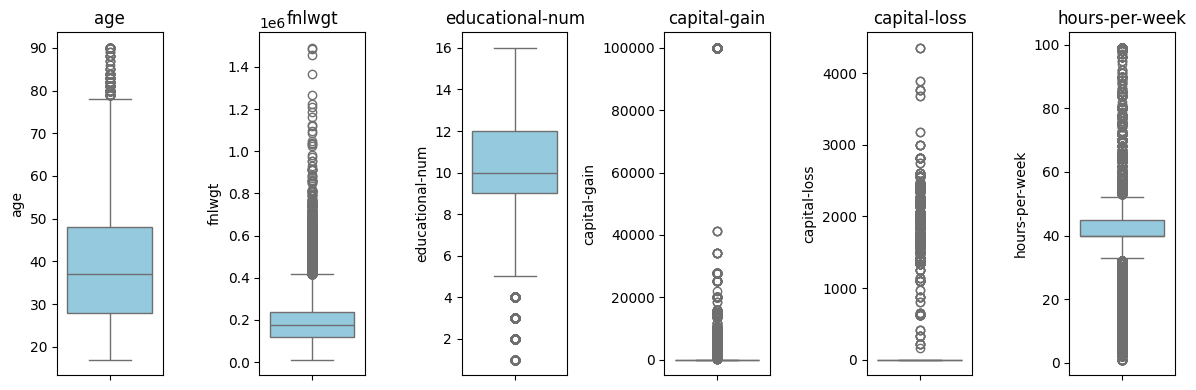

In [ ]:
# Checking Outliers in Individual Features
x = 0
#Numerical features;
numeric_columns = df.select_dtypes(include=['number']).columns

# Create a figure with specified size
plt.figure(figsize=(16, 4))

for col in numeric_columns:
    x += 1
    plt.subplot(1, 8, x)
    sns.boxplot(data=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

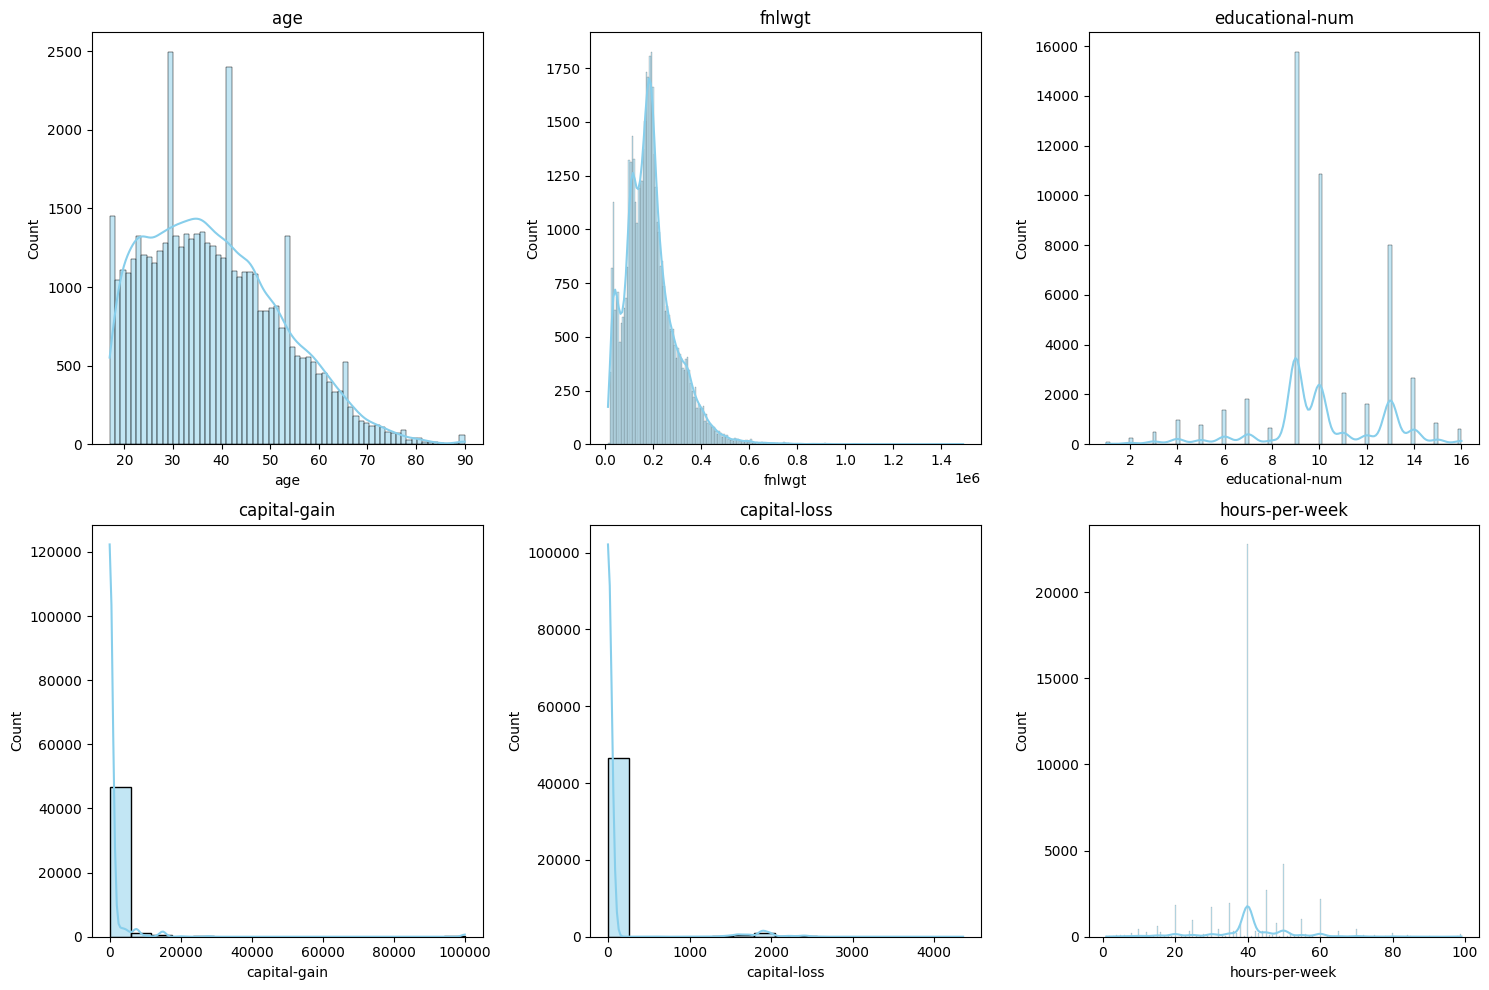

In [ ]:
columns = numeric_columns
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, column in enumerate(columns):
    sns.histplot(df[column], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(column)

for i in range(len(columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

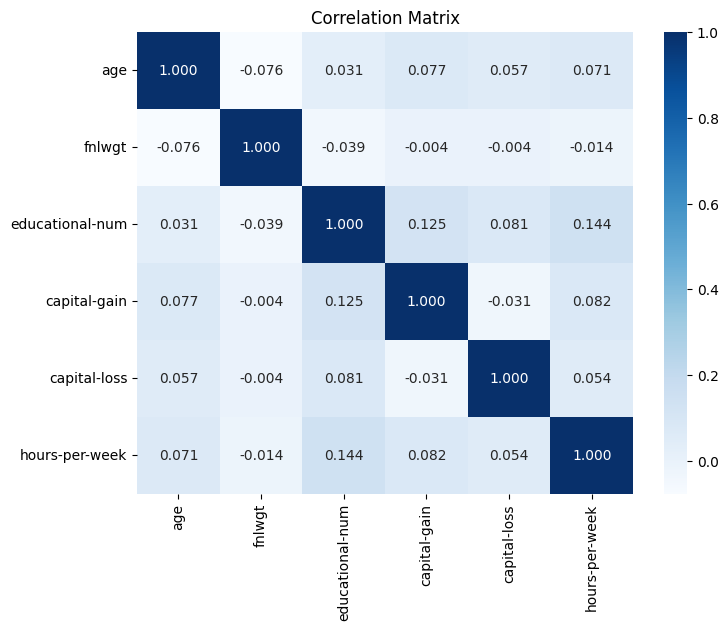

In [ ]:
numeric_columns = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_columns.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".3f", cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

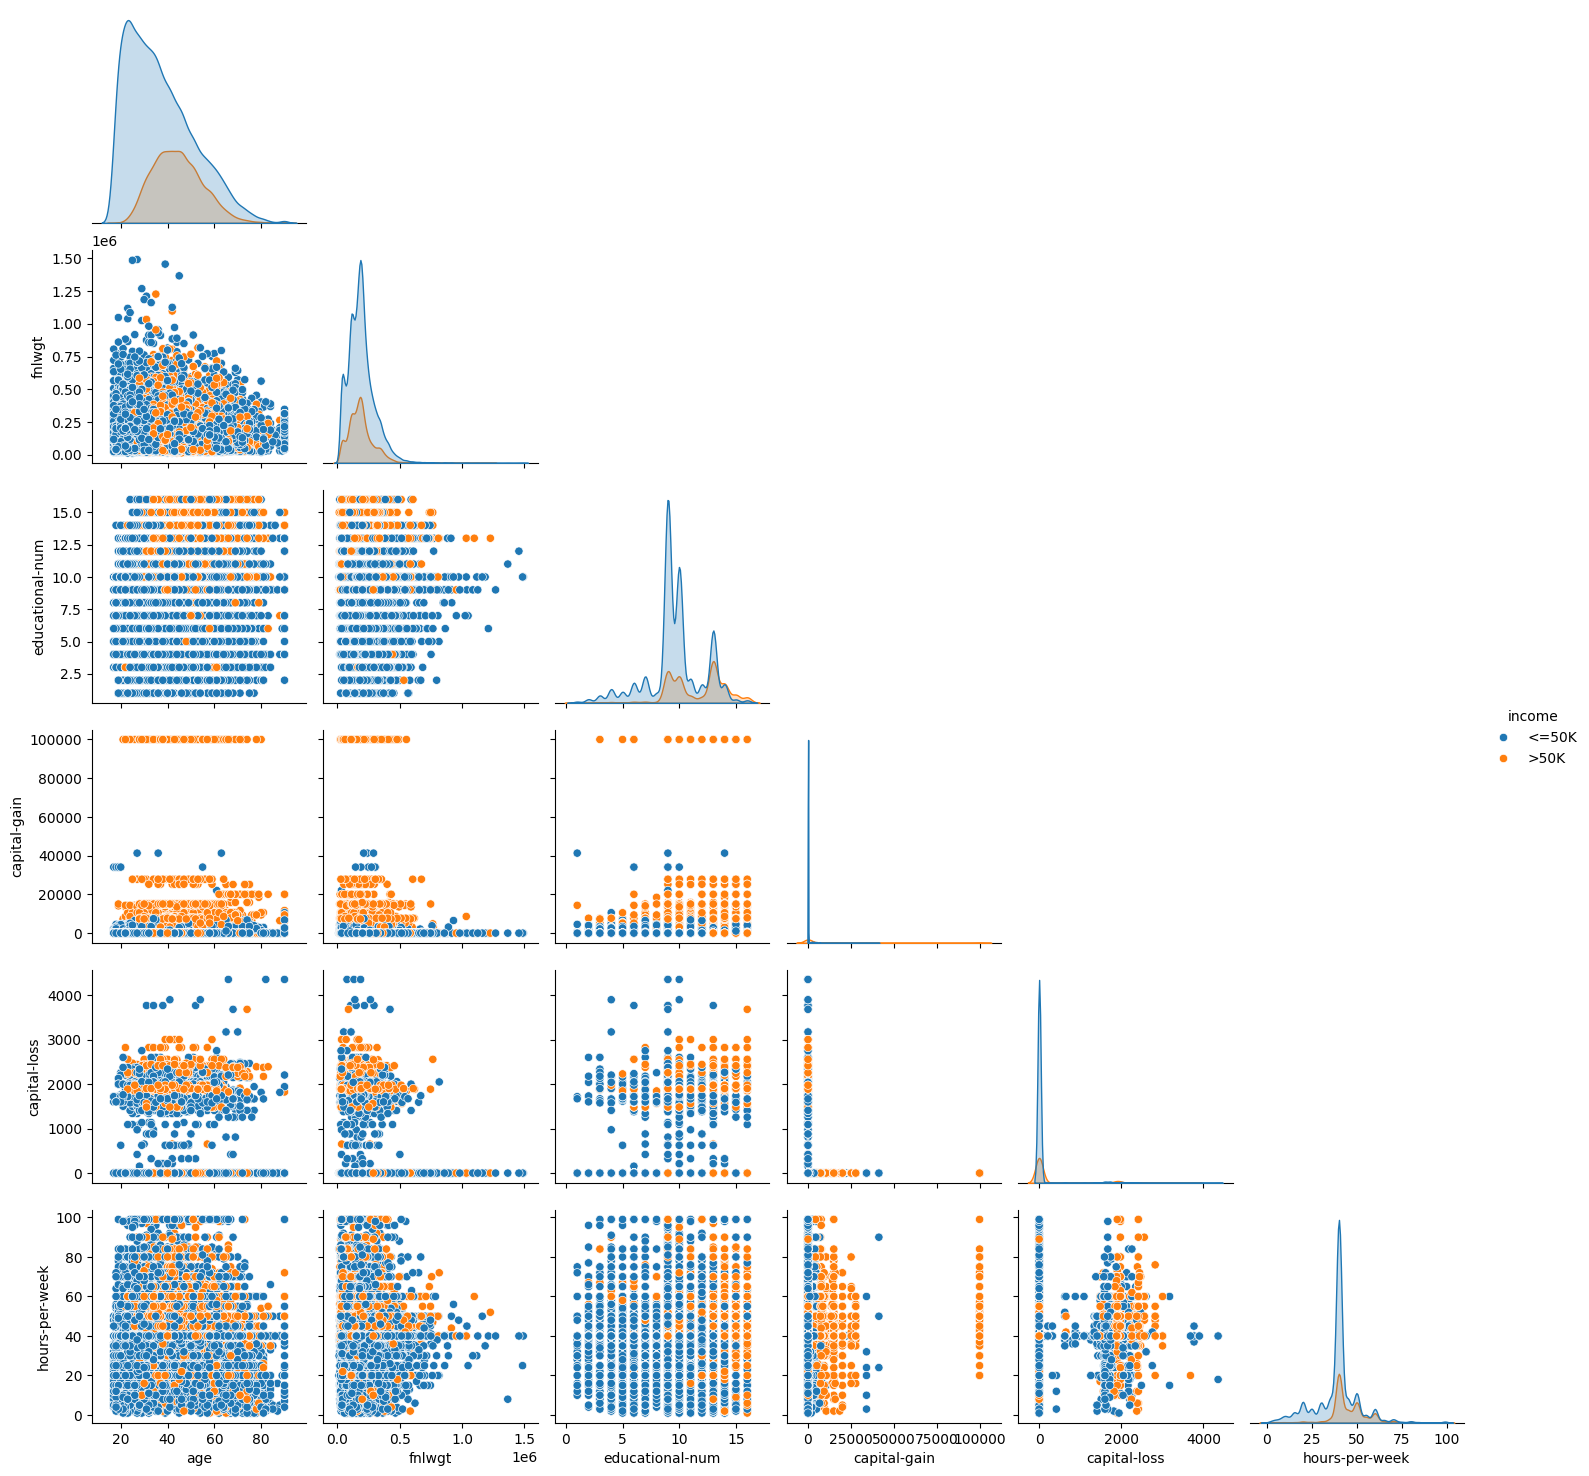

In [ ]:
sns.pairplot(df, hue="income", corner=True);

<h2 id="eda3" style="color: skyblue;">NaN Values</h2>

In [ ]:
df.isnull().sum()

age                   0
workclass          2795
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2805
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
income                0
dtype: int64

In [ ]:
print("Total number of NaN values:", df.isnull().sum().sum())
print("NaN values ​​are ", round((df.isnull().sum().sum() / len(df)) * 100, 3), "% of the data set.")

Total number of NaN values: 5600
NaN values ​​are  11.478 % of the data set.


<h3 id="nan1" style="color: steelblue;">NaN Values In "workclass" Column</h3>

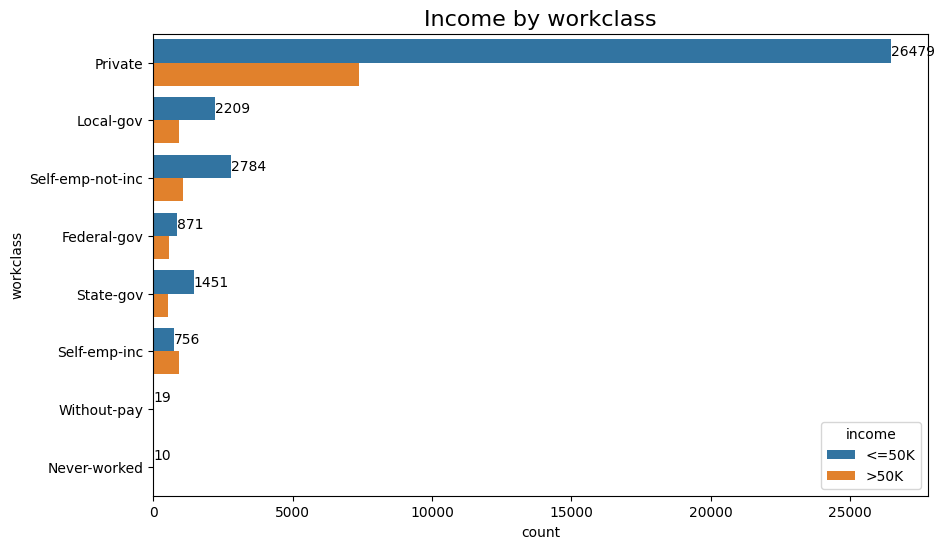

In [ ]:
plt.figure(figsize = (10,6))
ax = sns.countplot(y = df['workclass'], hue = df['income'])
plt.title("Income by workclass", fontsize = 16)
ax.bar_label(ax.containers[0]);

In [ ]:
df['workclass'] = df['workclass'].fillna('Private')

In [ ]:
df.workclass.isnull().sum()

np.int64(0)

<h3 id="nan2" style="color: steelblue;">NaN Values In "occupation" Column</h3>

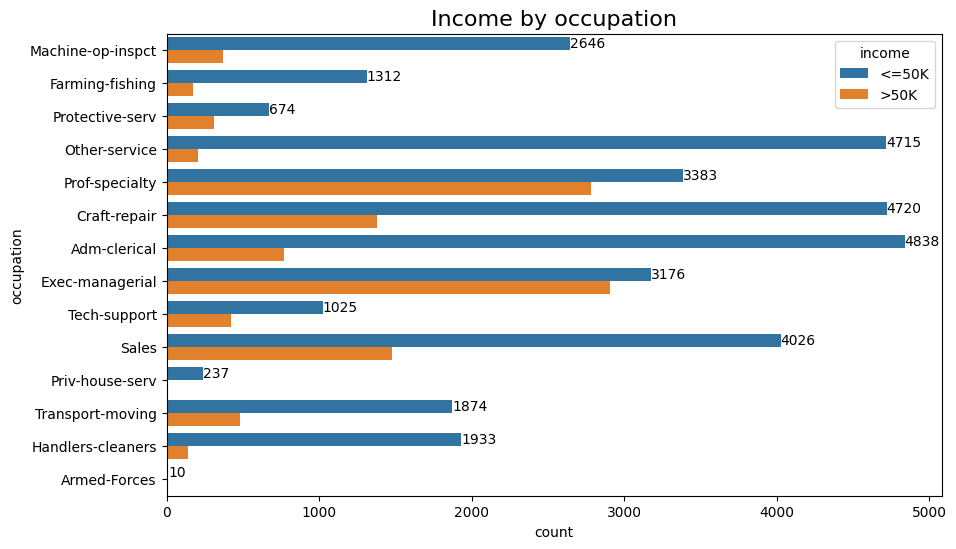

In [ ]:
plt.figure(figsize = (10,6))
ax = sns.countplot(y = df['occupation'], hue = df['income'])
plt.title("Income by occupation", fontsize = 16)
ax.bar_label(ax.containers[0]);

In [ ]:
modus_occupation = df['occupation'].mode()[0]
print(f"Modus occupation: '{modus_occupation}' ({df['occupation'].value_counts(normalize=True).iloc[0]*100:.1f}%)")
df['occupation'] = df['occupation'].fillna(modus_occupation)

Modus occupation: 'Prof-specialty' (13.4%)


In [ ]:
## CHECK
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])

In [ ]:
df.occupation.isnull().sum()

np.int64(0)

<h3 id="outlier1" style="color: steelblue;">"hours-per-week" Column</h3>

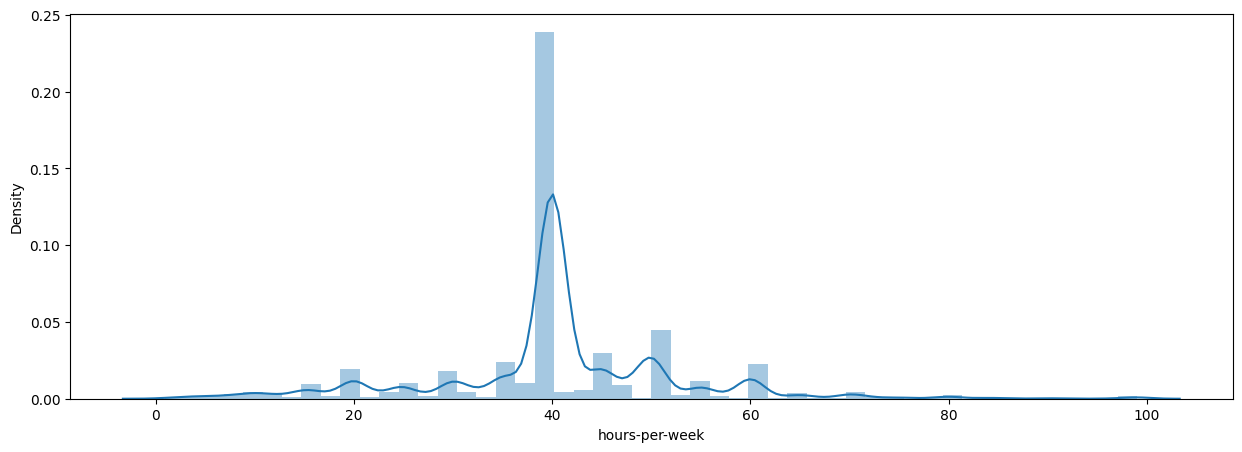

____________________________________________________________________________________________________
skewness in age column : 0.2396517078988374


In [ ]:
# Doing univariate analysis on workours column
plt.figure(figsize = (15,5))
sns.distplot(df["hours-per-week"], kde = True)

plt.show()
print("_"*100)
print("skewness in age column :",df["hours-per-week"].skew());

In [ ]:
df = df[~((df["hours-per-week"] > 72) | (df["hours-per-week"] < 20))]

<h3 id="outlier2" style="color: steelblue;">"capital-gain" & "capital-loss" Columns</h3>

In [ ]:
df['capital_diff'] = df['capital-gain'] - df['capital-loss']
df['capital_diff'] = pd.cut(df['capital_diff'], bins = [-5000, 5000, 100000], labels = ['Low', 'High'])
df['capital_diff'] = df['capital_diff'].astype('object')
df.drop(['capital-gain'], axis = 1, inplace = True)
df.drop(['capital-loss'], axis = 1, inplace = True)

def cap_outliers(df, lower_percentile=0.05, upper_percentile=0.95):
    for column in df.select_dtypes(include=np.number):  # Only apply to numeric columns
        lower_bound = df[column].quantile(lower_percentile)
        upper_bound = df[column].quantile(upper_percentile)
        df[column] = np.clip(df[column], lower_bound, upper_bound)
    return df

cap_outliers(df)

<h3 id="outlier3" style="color: steelblue;">"fnlwgt" Column</h3>

In [ ]:
df.drop(labels = ["fnlwgt"],axis = 1,inplace = True)

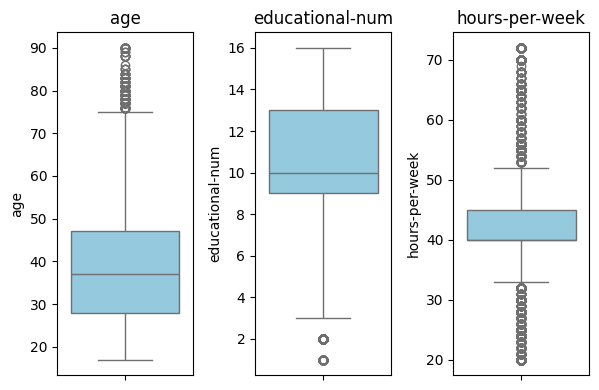

In [ ]:
# Checking Outliers in Individual Features
x = 0
#Numerical features;
numeric_columns = df.select_dtypes(include=['number']).columns

# Create a figure with specified size
plt.figure(figsize=(16, 4))

for col in numeric_columns:
    x += 1
    plt.subplot(1, 8, x)
    sns.boxplot(data=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

<h2 id="eda5" style="color: skyblue;">Feature Engineering</h2>

In [ ]:
# Removing rows where 'Workclass' is 'Without-pay' and 'Never-worked'
df = df[(df["workclass"] != "Without-pay") & (df["workclass"] != "Never-worked")]

In [ ]:
df["education"].replace(["11th", "9th", "7th-8th", "5th-6th", "10th", "1st-4th", "12th"], "School", inplace = True)

0              School
1             HS-grad
2          Assoc-acdm
3        Some-college
4        Some-college
             ...     
48837      Assoc-acdm
48838         HS-grad
48839         HS-grad
48840         HS-grad
48841         HS-grad
Name: education, Length: 45512, dtype: str

In [ ]:
df["race"].replace(["Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other"],"Others", inplace = True)

0        Black
1        White
2        White
3        Black
4        White
         ...  
48837    White
48838    White
48839    White
48840    White
48841    White
Name: race, Length: 45512, dtype: str

In [ ]:
df["marital-status"] = df["marital-status"].replace({
    "Married-civ-spouse": "Married",
    "Married-spouse-absent": "Married",
    "Married-AF-spouse": "Married",
    "Separated": "Single",
    "Never-married": "Single",
    "Divorced": "Single",
    "Widowed": "Single"
})

In [ ]:
df['income']=df['income'].map({'<=50K': 0, '>50K': 1})

In [ ]:
df.drop(columns=['education'], inplace=True)

In [ ]:
print(df[['educational-num']].corrwith(
    df['income']))

educational-num    0.334254
dtype: float64


In [ ]:
pd.crosstab(df['relationship'],
            df['marital-status'])

marital-status,Married,Single
relationship,,
Husband,18799,0
Not-in-family,325,11522
Other-relative,241,1158
Own-child,186,6281
Unmarried,176,4713
Wife,2111,0


[Text(0, 0, '34251'), Text(0, 0, '11261')]

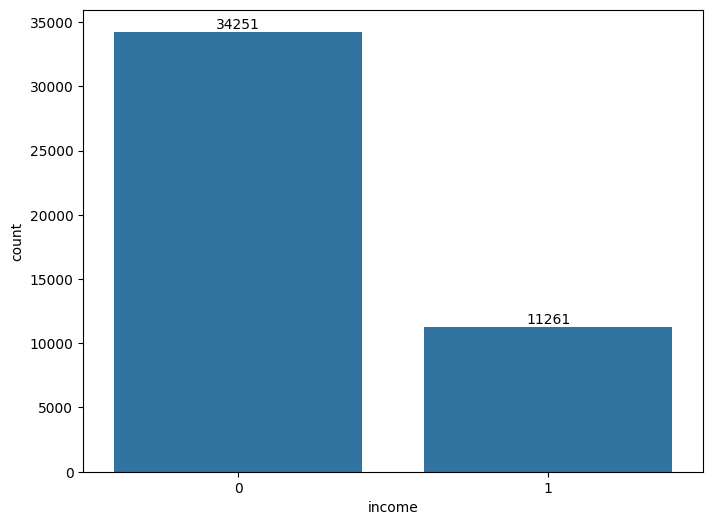

In [ ]:
ax = sns.countplot(x=df['income'])
ax.bar_label(ax.containers[0])

In [ ]:
df.drop(columns=["educational-num"], inplace=True)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 45512 entries, 0 to 48841
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45512 non-null  int64 
 1   workclass       45512 non-null  str   
 2   education       45512 non-null  str   
 3   marital-status  45512 non-null  str   
 4   occupation      45512 non-null  str   
 5   relationship    45512 non-null  str   
 6   race            45512 non-null  str   
 7   gender          45512 non-null  str   
 8   hours-per-week  45512 non-null  int64 
 9   income          45512 non-null  int64 
 10  capital_diff    45512 non-null  object
dtypes: int64(3), object(1), str(7)
memory usage: 6.6+ MB


<h1 id="data-pre" style="color: steelblue;">Data Pre-Processing</h1>

<h2 id="datapre1" style="color: skyblue;">Train | Test Split</h2>

In [ ]:
df.income.value_counts()

# <=50 : 0
# >50 : 1

# Unbalanced data

income
0    34251
1    11261
Name: count, dtype: int64

In [ ]:
X = df.drop(columns="income")
y = df.income

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101, stratify=y)

<h2 id="datapre2" style="color: skyblue;">Encoding</h2>

In [ ]:
cat_onehot = ['workclass', 'occupation', 'relationship', 'race', 'gender', 'marital-status']
cat_ordinal = ['education', 'capital_diff']

cat_for_edu = ['Preschool', 'School', 'HS-grad','Some-college', 'Assoc-voc', 'Assoc-acdm','Bachelors', 'Masters', 'Prof-school', 'Doctorate']
cat_for_capdiff = ['Low', 'High']

In [ ]:
column_trans = make_column_transformer((OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_onehot),
                                       (OrdinalEncoder(categories= [cat_for_edu, cat_for_capdiff]), cat_ordinal),
                                       remainder='passthrough')

In [ ]:
# Make copies to apply transformations locally within this cell
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Re-apply education replacement to X_train_processed and X_test_processed
X_train_processed["education"] = X_train_processed["education"].replace(["11th", "9th", "7th-8th", "5th-6th", "10th", "1st-4th", "12th"], "School")
X_test_processed["education"] = X_test_processed["education"].replace(["11th", "9th", "7th-8th", "5th-6th", "10th", "1st-4th", "12th"], "School")

# Re-apply race replacement
X_train_processed["race"] = X_train_processed["race"].replace(["Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other"],"Others")
X_test_processed["race"] = X_test_processed["race"].replace(["Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other"],"Others")

# Re-apply marital-status replacement
marital_status_replacements = {
    "Married-civ-spouse": "Married",
    "Married-spouse-absent": "Married",
    "Married-AF-spouse": "Married",
    "Separated": "Single",        #
    "Never-married": "Single",
    "Divorced": "Single",
    "Widowed": "Single"
}
X_train_processed["marital-status"] = X_train_processed["marital-status"].replace(marital_status_replacements)
X_test_processed["marital-status"] = X_test_processed["marital-status"].replace(marital_status_replacements)

X_train_trans = column_trans.fit_transform(X_train_processed)
X_test_trans = column_trans.transform(X_test_processed)

In [ ]:
column_trans.get_feature_names_out()

array(['onehotencoder__workclass_Federal-gov',
       'onehotencoder__workclass_Local-gov',
       'onehotencoder__workclass_Private',
       'onehotencoder__workclass_Self-emp-inc',
       'onehotencoder__workclass_Self-emp-not-inc',
       'onehotencoder__workclass_State-gov',
       'onehotencoder__occupation_Adm-clerical',
       'onehotencoder__occupation_Armed-Forces',
       'onehotencoder__occupation_Craft-repair',
       'onehotencoder__occupation_Exec-managerial',
       'onehotencoder__occupation_Farming-fishing',
       'onehotencoder__occupation_Handlers-cleaners',
       'onehotencoder__occupation_Machine-op-inspct',
       'onehotencoder__occupation_Other-service',
       'onehotencoder__occupation_Priv-house-serv',
       'onehotencoder__occupation_Prof-specialty',
       'onehotencoder__occupation_Protective-serv',
       'onehotencoder__occupation_Sales',
       'onehotencoder__occupation_Tech-support',
       'onehotencoder__occupation_Transport-moving',
       'oneh

In [ ]:
features = column_trans.get_feature_names_out()

In [ ]:
X_train= pd.DataFrame(X_train_trans, columns=features, index=X_train.index)
X_train.head()

,onehotencoder__workclass_Federal-gov,onehotencoder__workclass_Local-gov,onehotencoder__workclass_Private,onehotencoder__workclass_Self-emp-inc,onehotencoder__workclass_Self-emp-not-inc,onehotencoder__workclass_State-gov,onehotencoder__occupation_Adm-clerical,onehotencoder__occupation_Armed-Forces,onehotencoder__occupation_Craft-repair,onehotencoder__occupation_Exec-managerial,...,onehotencoder__race_Others,onehotencoder__race_White,onehotencoder__gender_Female,onehotencoder__gender_Male,onehotencoder__marital-status_Married,onehotencoder__marital-status_Single,ordinalencoder__education,ordinalencoder__capital_diff,remainder__age,remainder__hours-per-week
33413,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,4.0,0.0,66.0,40.0
7399,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,44.0,40.0
7621,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,3.0,0.0,23.0,35.0
46943,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,6.0,0.0,24.0,45.0
28212,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,5.0,0.0,32.0,40.0


In [ ]:
X_test= pd.DataFrame(X_test_trans, columns=features, index=X_test.index)
X_test.head()

,onehotencoder__workclass_Federal-gov,onehotencoder__workclass_Local-gov,onehotencoder__workclass_Private,onehotencoder__workclass_Self-emp-inc,onehotencoder__workclass_Self-emp-not-inc,onehotencoder__workclass_State-gov,onehotencoder__occupation_Adm-clerical,onehotencoder__occupation_Armed-Forces,onehotencoder__occupation_Craft-repair,onehotencoder__occupation_Exec-managerial,...,onehotencoder__race_Others,onehotencoder__race_White,onehotencoder__gender_Female,onehotencoder__gender_Male,onehotencoder__marital-status_Married,onehotencoder__marital-status_Single,ordinalencoder__education,ordinalencoder__capital_diff,remainder__age,remainder__hours-per-week
34269,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,3.0,0.0,54.0,35.0
27922,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,40.0,40.0
33124,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,4.0,0.0,36.0,37.0
40667,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,3.0,1.0,62.0,40.0
34834,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,41.0,40.0


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [ ]:
# ============================================================
# TRAINING DECISION TREE
# ============================================================

dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42
)

dt.fit(X_train_sm, y_train_sm)

# ADD THIS BLOCK RIGHT HERE ↓
print("="*50)
print("OVERFITTING CHECK")
print("="*50)
train_acc = dt.score(X_train, y_train)
test_acc  = dt.score(X_test, y_test)
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
diff = train_acc - test_acc
if diff > 0.05:
    print(f"  Gap of {diff:.4f} — possible overfitting")
elif test_acc < 0.75:
    print("  Low accuracy — possible underfitting")
else:
    print(" Model looks healthy")

OVERFITTING CHECK
Train Accuracy : 0.7919
Test  Accuracy : 0.7937
 Model looks healthy


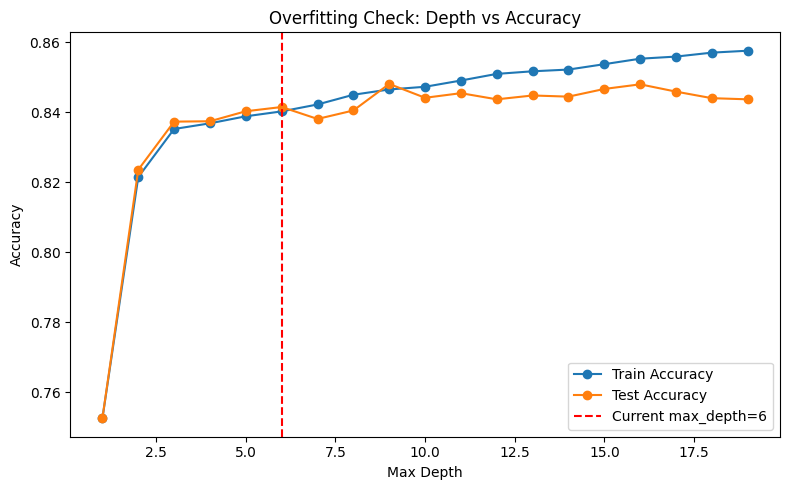

In [ ]:
# ADD THIS BLOCK RIGHT AFTER THE OVERFITTING CHECK ↓
train_scores, test_scores = [], []
depths = range(1, 20)

for d in depths:
    clf = DecisionTreeClassifier(
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        max_depth=d
    )
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

plt.figure(figsize=(8,5))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o')
plt.plot(depths, test_scores, label='Test Accuracy', marker='o')
plt.axvline(x=6, color='red', linestyle='--', label='Current max_depth=6')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Overfitting Check: Depth vs Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PREDIKSI
# ============================================================

y_prob = dt.predict_proba(X_test)[:,1]

# Ubah threshold
y_pred = (y_prob > 0.7).astype(int)

# ============================================================
# EVALUASI
# ============================================================

print("="*50)
print("CONFUSION MATRIX")
print("="*50)

cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)

print(classification_report(y_test, y_pred))

CONFUSION MATRIX
[[6464  387]
 [1081 1171]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      6851
           1       0.75      0.52      0.61      2252

    accuracy                           0.84      9103
   macro avg       0.80      0.73      0.76      9103
weighted avg       0.83      0.84      0.83      9103



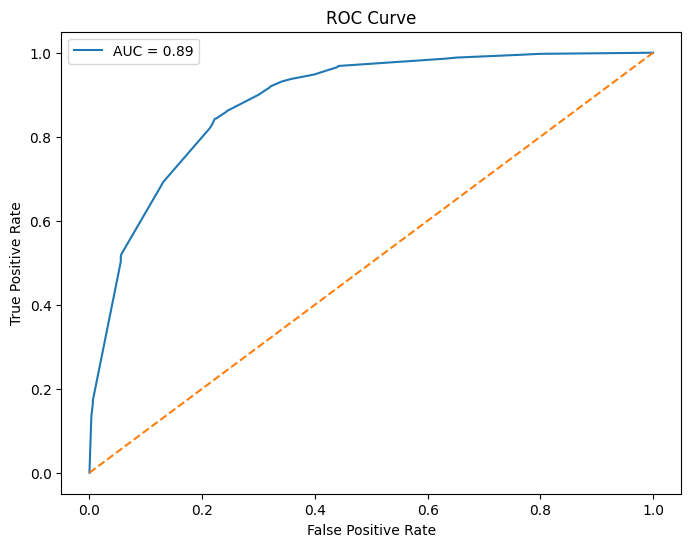

In [ ]:
# ============================================================
# ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

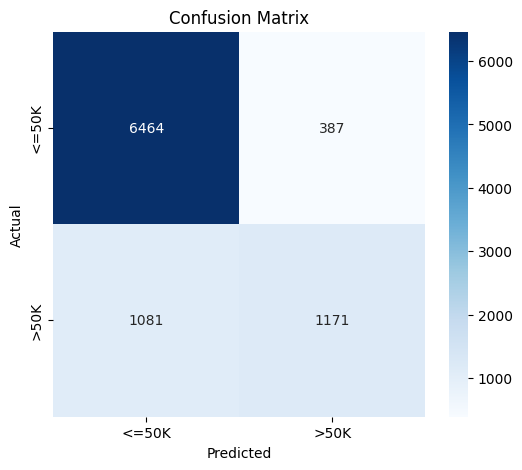

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["<=50K", ">50K"],
            yticklabels=["<=50K", ">50K"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

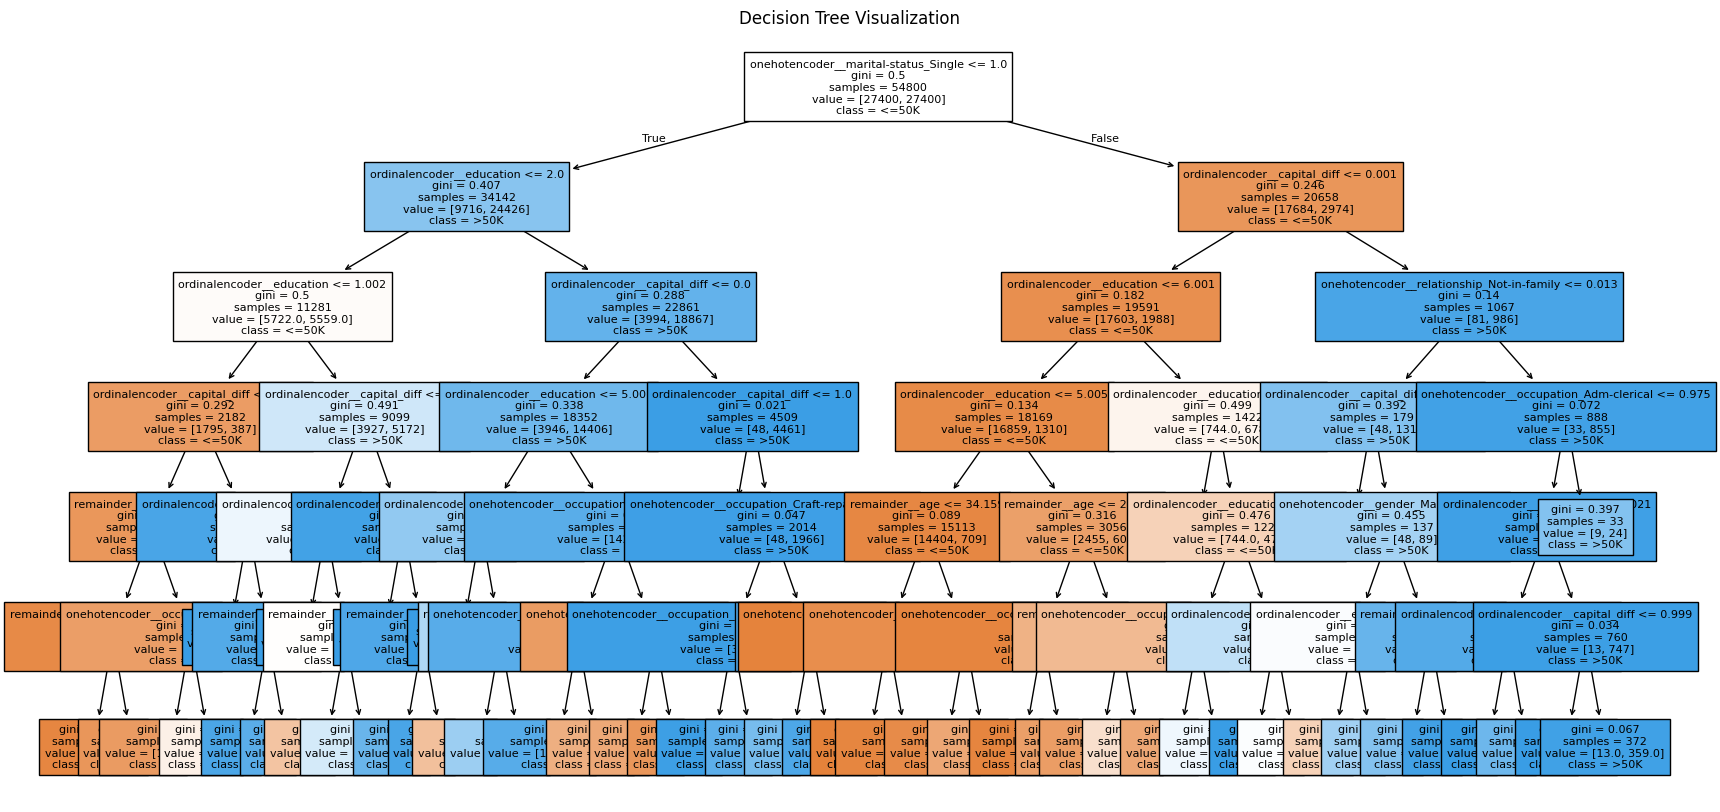

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=["<=50K", ">50K"],
    filled=True,
    fontsize=8
)
plt.title("Decision Tree Visualization")
plt.show()


Top 10 Feature Importance:
onehotencoder__marital-status_Single         0.562434
ordinalencoder__education                    0.249272
ordinalencoder__capital_diff                 0.140364
remainder__age                               0.029536
onehotencoder__relationship_Not-in-family    0.004427
remainder__hours-per-week                    0.004172
onehotencoder__occupation_Exec-managerial    0.004005
onehotencoder__occupation_Other-service      0.003989
onehotencoder__occupation_Sales              0.000846
onehotencoder__gender_Male                   0.000426
dtype: float64


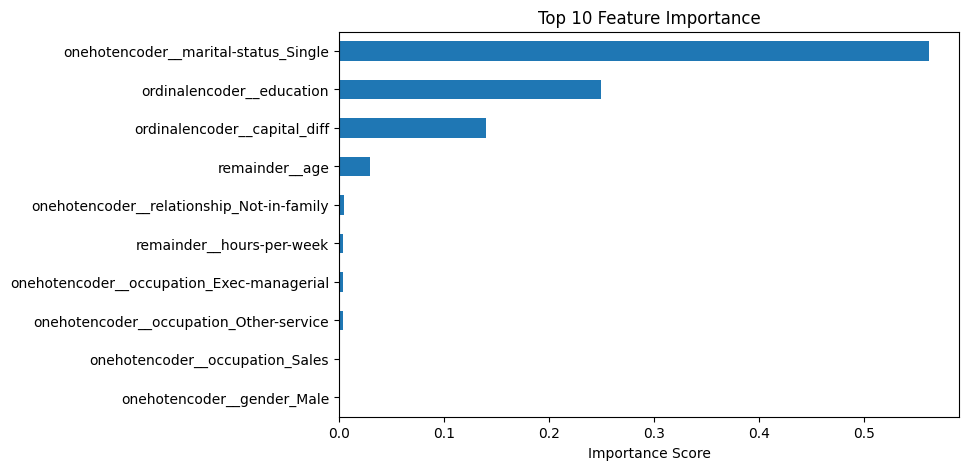

In [ ]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importances = pd.Series(dt.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("\nTop 10 Feature Importance:")
print(importances.head(10))

# Plot
importances.head(10).plot(kind='barh', figsize=(8,5))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.show()